In [847]:

#Importing dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from  xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

df = pd.read_csv("../data/survey_results_public.csv")




In [848]:
#Checking for the number of rows and  columns
df.shape

(64461, 61)

In [849]:
#Checking the columns that exists
df.columns

Index(['Respondent', 'MainBranch', 'Hobbyist', 'Age', 'Age1stCode', 'CompFreq',
       'CompTotal', 'ConvertedComp', 'Country', 'CurrencyDesc',
       'CurrencySymbol', 'DatabaseDesireNextYear', 'DatabaseWorkedWith',
       'DevType', 'EdLevel', 'Employment', 'Ethnicity', 'Gender', 'JobFactors',
       'JobSat', 'JobSeek', 'LanguageDesireNextYear', 'LanguageWorkedWith',
       'MiscTechDesireNextYear', 'MiscTechWorkedWith',
       'NEWCollabToolsDesireNextYear', 'NEWCollabToolsWorkedWith', 'NEWDevOps',
       'NEWDevOpsImpt', 'NEWEdImpt', 'NEWJobHunt', 'NEWJobHuntResearch',
       'NEWLearn', 'NEWOffTopic', 'NEWOnboardGood', 'NEWOtherComms',
       'NEWOvertime', 'NEWPurchaseResearch', 'NEWPurpleLink', 'NEWSOSites',
       'NEWStuck', 'OpSys', 'OrgSize', 'PlatformDesireNextYear',
       'PlatformWorkedWith', 'PurchaseWhat', 'Sexuality', 'SOAccount',
       'SOComm', 'SOPartFreq', 'SOVisitFreq', 'SurveyEase', 'SurveyLength',
       'Trans', 'UndergradMajor', 'WebframeDesireNextYear',
  

In [850]:
#Printing the first 5 rows of the dataframe
df.head()

,Respondent,MainBranch,Hobbyist,Age,Age1stCode,CompFreq,CompTotal,ConvertedComp,Country,CurrencyDesc,...,SurveyEase,SurveyLength,Trans,UndergradMajor,WebframeDesireNextYear,WebframeWorkedWith,WelcomeChange,WorkWeekHrs,YearsCode,YearsCodePro
0,1,I am a developer by profession,Yes,NaN,13,Monthly,NaN,NaN,Germany,European Euro,...,Neither easy nor difficult,Appropriate in length,No,"Computer science, computer engineering, or sof...",ASP.NET Core,ASP.NET;ASP.NET Core,Just as welcome now as I felt last year,50.0,36,27
1,2,I am a developer by profession,No,NaN,19,NaN,NaN,NaN,United Kingdom,Pound sterling,...,NaN,NaN,NaN,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat more welcome now than last year,NaN,7,4
2,3,I code primarily as a hobby,Yes,NaN,15,NaN,NaN,NaN,Russian Federation,NaN,...,Neither easy nor difficult,Appropriate in length,NaN,NaN,NaN,NaN,Somewhat more welcome now than last year,NaN,4,NaN
3,4,I am a developer by profession,Yes,25.0,18,NaN,NaN,NaN,Albania,Albanian lek,...,NaN,NaN,No,"Computer science, computer engineering, or sof...",NaN,NaN,Somewhat less welcome now than last year,40.0,7,4
4,5,"I used to be a developer by profession, but no...",Yes,31.0,16,NaN,NaN,NaN,United States,NaN,...,Easy,Too short,No,"Computer science, computer engineering, or sof...",Django;Ruby on Rails,Ruby on Rails,Just as welcome now as I felt last year,NaN,15,8


In [851]:
df = df[["Country", "EdLevel", "YearsCodePro", "Employment", "ConvertedComp", "WebframeWorkedWith", "UndergradMajor"]]
df = df.rename({"ConvertedComp": "Salary"}, axis=1)
df.head()

,Country,EdLevel,YearsCodePro,Employment,Salary,WebframeWorkedWith,UndergradMajor
0,Germany,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",27,"Independent contractor, freelancer, or self-em...",NaN,ASP.NET;ASP.NET Core,"Computer science, computer engineering, or sof..."
1,United Kingdom,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",4,Employed full-time,NaN,NaN,"Computer science, computer engineering, or sof..."
2,Russian Federation,NaN,NaN,NaN,NaN,NaN,NaN
3,Albania,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",4,NaN,NaN,NaN,"Computer science, computer engineering, or sof..."
4,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",8,Employed full-time,NaN,Ruby on Rails,"Computer science, computer engineering, or sof..."


In [852]:
df = df[df["Salary"].notnull()]
df.head()

,Country,EdLevel,YearsCodePro,Employment,Salary,WebframeWorkedWith,UndergradMajor
7,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",13,Employed full-time,116000.0,Flask,"Computer science, computer engineering, or sof..."
9,United Kingdom,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",4,Employed full-time,32315.0,Flask;jQuery,Mathematics or statistics
10,United Kingdom,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",2,Employed full-time,40070.0,Angular;Angular.js;Django;React.js,"Computer science, computer engineering, or sof..."
11,Spain,Some college/university study without earning ...,7,Employed full-time,14268.0,ASP.NET;jQuery,Mathematics or statistics
12,Netherlands,"Secondary school (e.g. American high school, G...",20,Employed full-time,38916.0,NaN,NaN


In [853]:
#getting more information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34756 entries, 7 to 64154
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             34756 non-null  object 
 1   EdLevel             34188 non-null  object 
 2   YearsCodePro        34621 non-null  object 
 3   Employment          34717 non-null  object 
 4   Salary              34756 non-null  float64
 5   WebframeWorkedWith  26159 non-null  object 
 6   UndergradMajor      32228 non-null  object 
dtypes: float64(1), object(6)
memory usage: 2.1+ MB


In [854]:
df.describe()

,Salary
count,3.475600e+04
mean,1.037561e+05
std,2.268853e+05
min,0.000000e+00
25%,2.464800e+04
50%,5.404900e+04
75%,9.500000e+04
max,2.000000e+06


In [855]:
#Checking for missing values
df.isnull().sum()

Country                  0
EdLevel                568
YearsCodePro           135
Employment              39
Salary                   0
WebframeWorkedWith    8597
UndergradMajor        2528
dtype: int64

In [856]:
#dropping missing values in the dataset
df.dropna(inplace=True)

In [857]:
df.isnull().sum()

Country               0
EdLevel               0
YearsCodePro          0
Employment            0
Salary                0
WebframeWorkedWith    0
UndergradMajor        0
dtype: int64

In [858]:
#checking for duplicates
df.duplicated().sum()

np.int64(63)

In [859]:
#removing duplicates

df.drop_duplicates(inplace=True)  


In [860]:
df["Employment"].unique()


array(['Employed full-time',
       'Independent contractor, freelancer, or self-employed',
       'Employed part-time'], dtype=object)

In [861]:
# Keep only full-time and part-time employees
df = df[df["Employment"].isin(["Employed full-time", "Employed part-time"])]
# Drop just the contractor/freelancer rows
df = df[df["Employment"] != "Independent contractor, freelancer, or self-employed"]


In [862]:
df["Employment"].unique()


array(['Employed full-time', 'Employed part-time'], dtype=object)

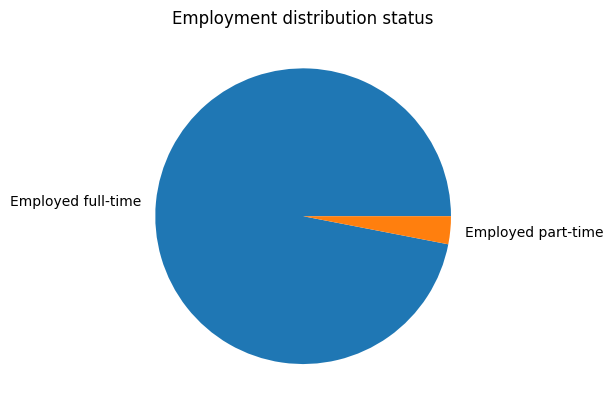

In [863]:
df["Employment"].value_counts().sort_values(ascending=False).plot(kind = "pie")
plt.title("Employment distribution status")
plt.ylabel("")
plt.show()

In [864]:
df.head(2)

,Country,EdLevel,YearsCodePro,Employment,Salary,WebframeWorkedWith,UndergradMajor
7,United States,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",13,Employed full-time,116000.0,Flask,"Computer science, computer engineering, or sof..."
9,United Kingdom,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",4,Employed full-time,32315.0,Flask;jQuery,Mathematics or statistics


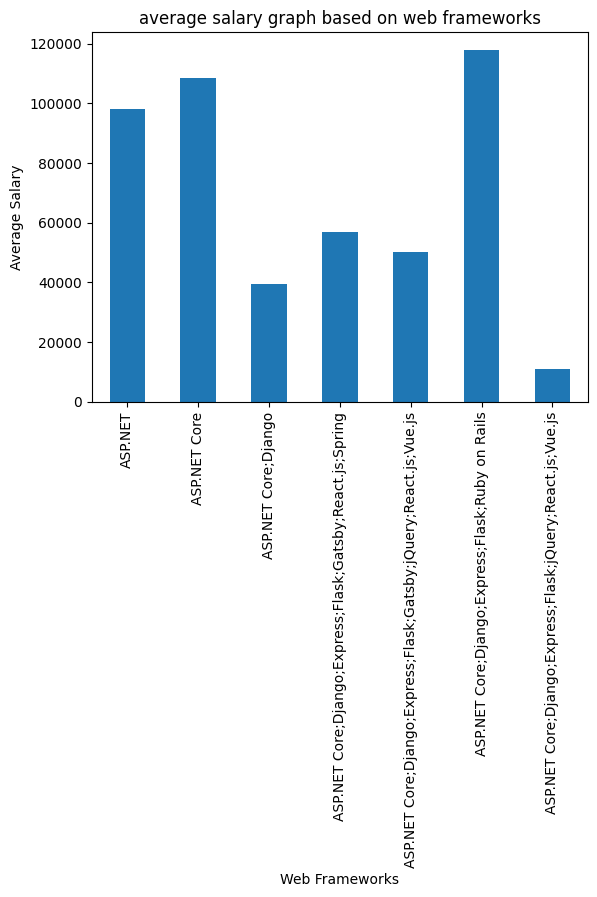

In [865]:
df.groupby("WebframeWorkedWith")["Salary"].mean().head(7).plot(kind="bar")
plt.title("average salary graph based on web frameworks")
plt.xlabel("Web Frameworks")
plt.ylabel("Average Salary")
plt.show()

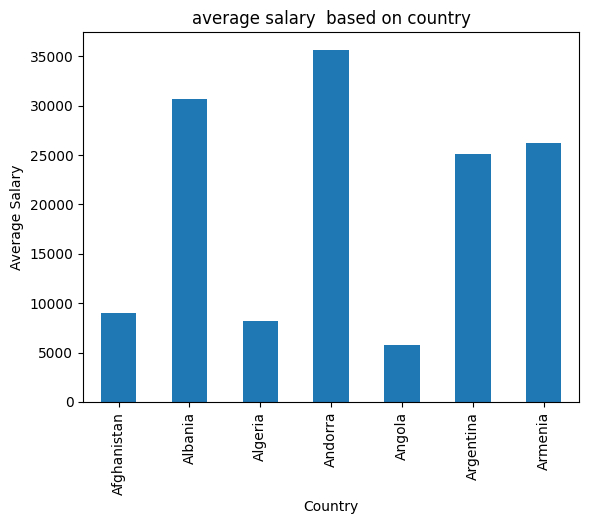

In [866]:
#checking the salary rate per country
df.groupby("Country")["Salary"].mean().head(7).plot(kind="bar")
plt.title("average salary  based on country")
plt.xlabel("Country")
plt.ylabel("Average Salary")
plt.show()

In [867]:
df["Country"].value_counts()



Country
United States     5371
India             1780
United Kingdom    1527
Germany           1207
Canada             847
                  ... 
Angola               1
Senegal              1
Belize               1
Yemen                1
Andorra              1
Name: count, Length: 153, dtype: int64

In [868]:
def shorten_categories(categories, cutoff):
    categorical_map = {}
    for i in range(len(categories)):
        if categories .values[i] >= cutoff:
            categorical_map[categories.index[i]] = categories.index[i]
        else:
            categorical_map[categories.index[i]] = "other"
    return categorical_map

In [869]:
country_map = shorten_categories(df.Country.value_counts(), 400)
df["Country"] = df["Country"].map(country_map)
df.Country.value_counts()

Country
other             7387
United States     5371
India             1780
United Kingdom    1527
Germany           1207
Canada             847
Brazil             768
France             697
Netherlands        518
Australia          493
Spain              481
Poland             401
Name: count, dtype: int64

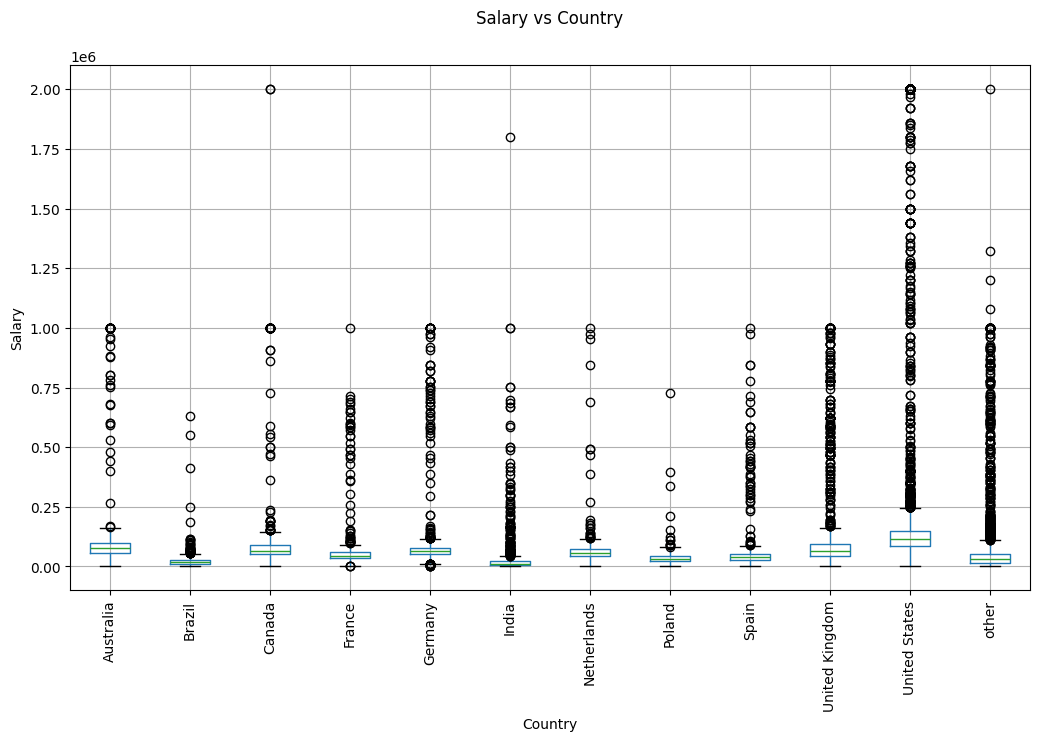

In [870]:
fig, ax = plt.subplots(1,1,figsize=(12,7))
df.boxplot("Salary","Country",ax=ax)
plt.suptitle("Salary vs Country")
plt.title("")
plt.ylabel("Salary")
plt.xticks(rotation=90)
plt.show()

In [871]:
df = df[df["Salary"] <=250000]
df = df[df["Salary"] >=10000]


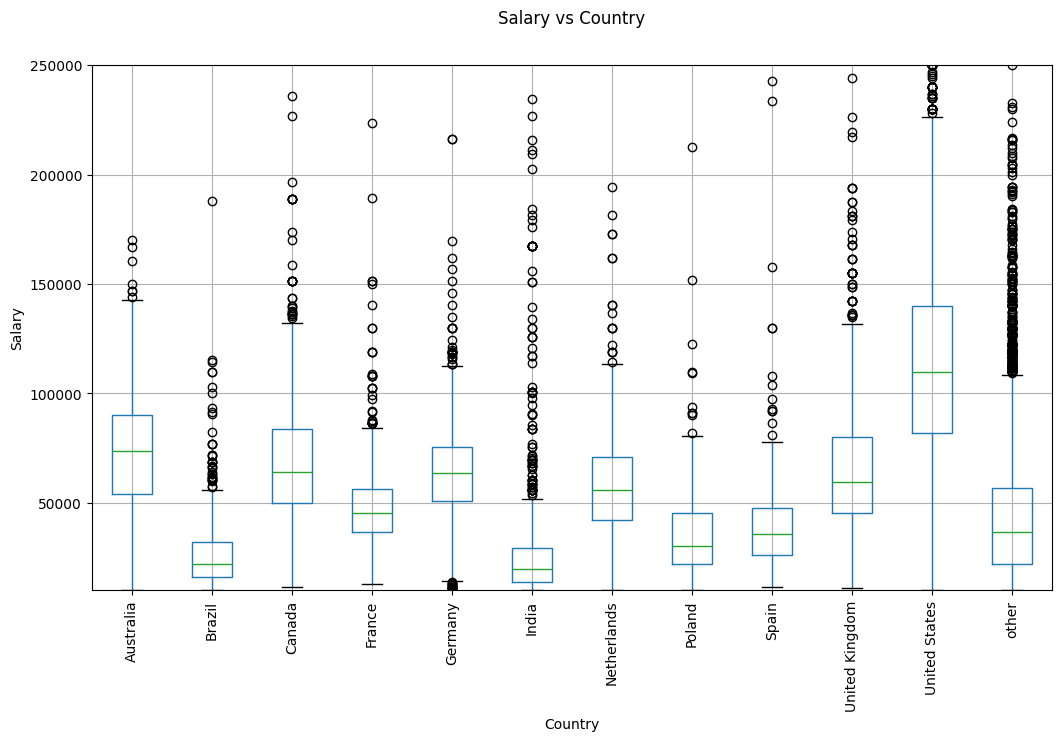

In [872]:
fig, ax = plt.subplots(1,1,figsize=(12,7))
df.boxplot("Salary","Country",ax=ax)
plt.suptitle("Salary vs Country")
plt.title("")
plt.ylabel("Salary")
plt.ylim(10000, 250000)  # Keep the y-axis in a reasonable range
plt.xticks(rotation=90)
plt.show()

In [873]:
df["YearsCodePro"].unique()

array(['13', '4', '2', '7', '1', '3', '10', '14', '12', '20', '29', '28',
       '8', '23', '15', '25', '9', '11', 'Less than 1 year', '5', '21',
       '16', '6', '18', '32', '19', '22', '38', '30', '17', '26', '27',
       '24', '34', '33', '36', '40', '35', '39', '41', '31', '45', '37',
       '42', '44', '43', '49'], dtype=object)

In [874]:
def clean_experience(x):
    if x == "More than 50 years":
        return 50
    if x == "Less than 1 year":
        return 0.5
    return float(x)
df["YearsCodePro"] = df["YearsCodePro"].apply(clean_experience)

In [875]:
df["EdLevel"].unique()

array(['Bachelor’s degree (B.A., B.S., B.Eng., etc.)',
       'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)',
       'Some college/university study without earning a degree',
       'Associate degree (A.A., A.S., etc.)',
       'Other doctoral degree (Ph.D., Ed.D., etc.)',
       'Professional degree (JD, MD, etc.)'], dtype=object)

In [876]:
def clean_education(x):
   
     if "Bachelor’s degree" in x:
        return "Bachelor’s degree"
     if "Master’s degree" in x:
        return "Master’s degree"
     if "Professional degree" in x or "Other doctoral" in x:
        return "Post grad"
     return "less than a Bachelor’s"
   

df["EdLevel"] = df["EdLevel"].apply(clean_education)

In [877]:
df["EdLevel"].unique()

array(['Bachelor’s degree', 'Master’s degree', 'less than a Bachelor’s',
       'Post grad'], dtype=object)

In [878]:
df["Employment"].unique()


array(['Employed full-time', 'Employed part-time'], dtype=object)

In [879]:
df["Employment"].value_counts()


Employment
Employed full-time    17592
Employed part-time      468
Name: count, dtype: int64

In [880]:
def clean_employment(x):
    if x == "Employed full-time":
        return "full-time"
    elif x == "Employed part-time":
        return "part-time"

df["Employment"] = df["Employment"].apply(clean_employment)


In [881]:
df["Employment"].unique()

array(['full-time', 'part-time'], dtype=object)

In [882]:
df["UndergradMajor"].value_counts()

UndergradMajor
Computer science, computer engineering, or software engineering                   11521
Information systems, information technology, or system administration              1456
Another engineering discipline (such as civil, electrical, mechanical, etc.)       1403
A natural science (such as biology, chemistry, physics, etc.)                       704
Web development or web design                                                       565
Mathematics or statistics                                                           562
A business discipline (such as accounting, finance, marketing, etc.)                490
A humanities discipline (such as literature, history, philosophy, etc.)             459
A social science (such as anthropology, psychology, political science, etc.)        369
Fine arts or performing arts (such as graphic design, music, studio art, etc.)      347
I never declared a major                                                            119
A health science 

In [883]:
def clean_undergrad_major(x):
    if pd.isnull(x):
        return "Unknown"
    
    x = x.lower()  # make lowercase for easier matching
    
    if "computer science" in x or "software engineering" in x or "computer engineering" in x:
        return "CS/Software Eng"
    elif "information systems" in x or "information technology" in x or "system administration" in x:
        return "IT/Systems"
    elif "engineering" in x:
        return "Other Engineering"
    elif "natural science" in x:
        return "Natural Sciences"
    elif "web development" in x or "web design" in x:
        return "Web Dev/Design"
    elif "mathematics" in x or "statistics" in x:
        return "Math/Stats"
    elif "business" in x:
        return "Business"
    elif "humanities" in x:
        return "Humanities"
    elif "social science" in x:
        return "Social Sciences"
    elif "fine arts" in x or "performing arts" in x:
        return "Arts"
    elif "never declared" in x:
        return "Undeclared"
    elif "health science" in x:
        return "Health Sciences"
    else:
        return "Other"  # catch any unusual entries

# Apply to the DataFrame
df["UndergradMajor"] = df["UndergradMajor"].apply(clean_undergrad_major)


In [884]:
df["UndergradMajor"].unique()

array(['CS/Software Eng', 'Math/Stats', 'IT/Systems', 'Natural Sciences',
       'Arts', 'Undeclared', 'Other Engineering', 'Humanities',
       'Health Sciences', 'Social Sciences', 'Web Dev/Design', 'Business'],
      dtype=object)

In [885]:
df["WebframeWorkedWith"].value_counts()

WebframeWorkedWith
React.js                                                                                 887
Spring                                                                                   662
jQuery                                                                                   577
Flask                                                                                    459
ASP.NET;ASP.NET Core                                                                     406
                                                                                        ... 
Angular;Angular.js;Django;Drupal;Express;jQuery;Laravel;React.js;Ruby on Rails;Vue.js      1
Angular;Angular.js;ASP.NET;ASP.NET Core;Express;Flask                                      1
Angular;Angular.js;Flask;jQuery;React.js                                                   1
Angular;ASP.NET Core;Express;jQuery;React.js;Vue.js                                        1
Angular;Angular.js;Django;Drupal;Express;Flask     

In [886]:
def shorten_categories(categories, cutoff):
    categorical_map = {}
    for i in range(len(categories)):
        if categories .values[i] >= cutoff:
            categorical_map[categories.index[i]] = categories.index[i]
        else:
            categorical_map[categories.index[i]] = "other"
    return categorical_map


In [887]:
webframeWorkedWith_map = shorten_categories(df.WebframeWorkedWith.value_counts(), 400)
df["WebframeWorkedWith"] = df["WebframeWorkedWith"].map(webframeWorkedWith_map)
df.WebframeWorkedWith.value_counts()

WebframeWorkedWith
other                          14669
React.js                         887
Spring                           662
jQuery                           577
Flask                            459
ASP.NET;ASP.NET Core             406
ASP.NET;ASP.NET Core;jQuery      400
Name: count, dtype: int64

In [888]:
df["WebframeWorkedWith"].unique()

array(['Flask', 'other', 'ASP.NET;ASP.NET Core', 'jQuery', 'React.js',
       'Spring', 'ASP.NET;ASP.NET Core;jQuery'], dtype=object)

In [889]:
#frameworks we want to keep
allowed_frameworks = ["React.js", "Spring","Flask","other"]



In [890]:
#dropping the other frameworks
allowed_frameworks = ["React.js", "Spring","Flask", "other"]
df = df[df["WebframeWorkedWith"].isin(allowed_frameworks)]




In [891]:
df["WebframeWorkedWith"].value_counts()

WebframeWorkedWith
other       14669
React.js      887
Spring        662
Flask         459
Name: count, dtype: int64

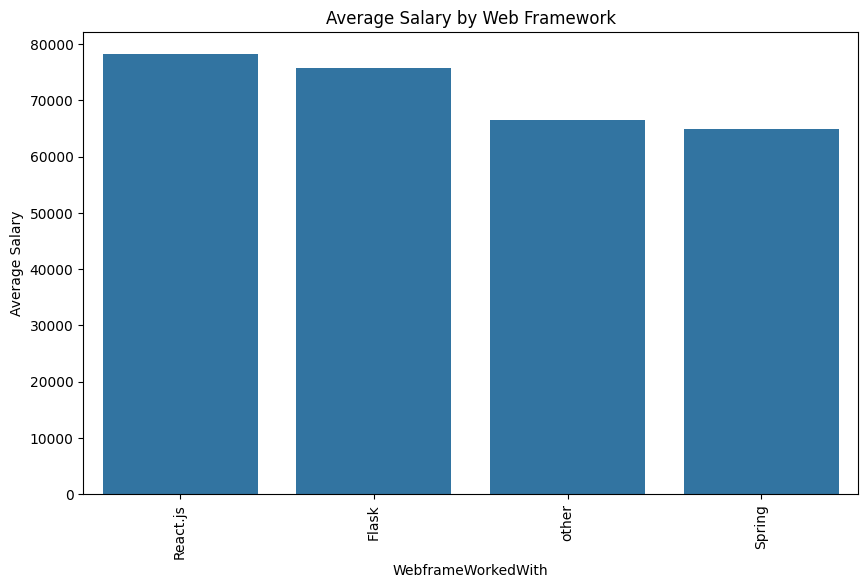

In [892]:
avg_salary = df.groupby("WebframeWorkedWith")["Salary"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_salary.index, y=avg_salary.values)
plt.xticks(rotation=90)
plt.ylabel("Average Salary")
plt.title("Average Salary by Web Framework")
plt.show()

In [893]:
#label encoding
le_education = LabelEncoder()
le_education.fit(df["EdLevel"])
df["EdLevel"] = le_education.transform(df["EdLevel"])
df["EdLevel"].unique()


array([0, 1, 3, 2])

In [894]:
le_country = LabelEncoder()
df["Country"] = le_country.fit_transform(df["Country"])
df["Country"].unique()


array([10,  9,  8,  2, 11,  3,  1,  4,  6,  5,  7,  0])

In [895]:
le_employment = LabelEncoder()
df["Employment"] = le_employment.fit_transform(df["Employment"])
df["Employment"].unique()

array([0, 1])

In [896]:
le_undergradmajor = LabelEncoder()
df["UndergradMajor"] = le_undergradmajor.fit_transform(df["UndergradMajor"])
df["UndergradMajor"].unique()

array([ 2,  6,  5,  7,  0, 10,  8,  4,  3,  9, 11,  1])

In [897]:
le_webfameworkedwith = LabelEncoder()
df["WebframeWorkedWith"] = le_webfameworkedwith.fit_transform(df["WebframeWorkedWith"])
df["WebframeWorkedWith"].unique()

array([0, 3, 1, 2])

In [898]:
#splitting data into features and target
X= df.drop("Salary", axis=1)
y = df["Salary"]


In [899]:
print(X)

       Country  EdLevel  YearsCodePro  Employment  WebframeWorkedWith  \
7           10        0          13.0           0                   0   
9            9        1           4.0           0                   3   
10           9        0           2.0           0                   3   
11           8        3           7.0           0                   3   
13          10        3           1.0           0                   3   
...        ...      ...           ...         ...                 ...   
63980        1        3           7.0           0                   3   
64013       10        1          30.0           0                   3   
64048        5        0           3.0           0                   3   
64053        5        0          18.0           0                   1   
64122       10        3           4.0           0                   3   

       UndergradMajor  
7                   2  
9                   6  
10                  2  
11                  6  
13 

In [900]:
print(y)

7        116000.0
9         32315.0
10        40070.0
11        14268.0
13        66000.0
           ...   
63980     11544.0
64013    200000.0
64048     16754.0
64053     75396.0
64122     70000.0
Name: Salary, Length: 16677, dtype: float64


In [901]:
#Model Training
#Linear Regression


#loading the linear regression model
linear_reg= LinearRegression()
linear_reg.fit(X,y.values)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [902]:
y_pred = linear_reg.predict(X)

In [903]:
error = np.sqrt(mean_squared_error(y, y_pred))

In [904]:
error

np.float64(41912.17709285081)

In [905]:
error = metrics.r2_score(y, y_pred)

In [906]:
error

0.16446259515085881

In [907]:
error = np.sqrt(mean_absolute_error(y, y_pred))

In [908]:
error

np.float64(180.61233834314092)

In [909]:
#Model Training
#Random Forest Regressor
#Loading the moodel

random_forest_reg = RandomForestRegressor(random_state=0)
random_forest_reg.fit(X,y.values)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [910]:
y_pred = random_forest_reg.predict(X)

In [911]:
error = np.sqrt(mean_squared_error(y, y_pred))
print("${:,.02f}".format(error))

$25,225.42


In [912]:
error = np.sqrt(mean_absolute_error(y, y_pred))
print("${:,.02f}".format(error))

$131.27


In [913]:
#Model training
#Deision Tree Regresor
#Loading the model

dec_tree_reg = DecisionTreeRegressor(random_state=0)
dec_tree_reg.fit(X, y.values)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_le

In [914]:
y_pred = dec_tree_reg.predict(X)


In [915]:
error = np.sqrt(mean_squared_error(y, y_pred))
print("${:,.02f}".format(error))

$24,652.57


In [916]:
error = np.sqrt(mean_absolute_error(y, y_pred))
print("${:,.02f}".format(error))

$125.24


In [917]:
max_depth = [None,2,4,6,8,10,12]
parameters = {"max_depth": max_depth}

regressor = DecisionTreeRegressor(random_state=0)
gs = GridSearchCV(regressor, parameters, scoring=['neg_mean_squared_error', 'neg_mean_absolute_error'], refit='neg_mean_squared_error')
gs.fit(X, y.values)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['neg_mean_squared_error', 'neg_mean_absolute_error']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is disp

In [918]:
regressor = gs.best_estimator_
y_pred = regressor.predict(X)
error = np.sqrt(mean_squared_error(y,y_pred))
print("${:,.02f}".format(error))

$29,372.15


In [919]:
regressor = gs.best_estimator_
y_pred = regressor.predict(X)
error = np.sqrt(mean_absolute_error(y,y_pred))
print("${:,.02f}".format(error))

$144.16


In [920]:
X

,Country,EdLevel,YearsCodePro,Employment,WebframeWorkedWith,UndergradMajor
7,10,0,13.0,0,0,2
9,9,1,4.0,0,3,6
10,9,0,2.0,0,3,2
11,8,3,7.0,0,3,6
13,10,3,1.0,0,3,2
...,...,...,...,...,...,...
63980,1,3,7.0,0,3,11
64013,10,1,30.0,0,3,8
64048,5,0,3.0,0,3,2
64053,5,0,18.0,0,1,8


In [921]:
#country,Edlevel,yearscodePro,Employment,webframe,undergradmajor
X = np.array([["United States","Bachelor’s degree",15,"full-time","other","CS/Software Eng"]])
X

array([['United States', 'Bachelor’s degree', '15', 'full-time', 'other',
        'CS/Software Eng']], dtype='<U21')

In [922]:


X[:, 0] = le_country.transform(X[:, 0])
X[:, 1] = le_education.transform(X[:, 1])
X[:, 3] = le_employment.transform(X[:, 3])
X[:, 4] = le_webfameworkedwith.transform(X[:,4])
X[:, 5] = le_undergradmajor.transform(X[:, 5])
X = X.astype(float)
X

array([[10.,  0., 15.,  0.,  3.,  2.]])

In [923]:
y_pred = regressor.predict(X)
y_pred

c:\Users\Admin\Desktop\salary_prediction_system\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([133723.89761092])

In [924]:
#saving the model
import pickle


In [925]:
data = {"model":regressor,"le_country":le_country,"le_education":le_education,"le_employment":le_employment,"le_webfameworkedwith":le_webfameworkedwith,"le_undergradmajor":le_undergradmajor}
with open ("saved_steps.pkl","wb")as file:
    pickle.dump(data,file)


In [926]:
with open ("saved_steps.pkl","rb")as file:
    data = pickle.load(file)

regressor_loaded = data["model"]
le_country = data["le_country"]
le_education = data["le_education"]
le_employment = data["le_employment"]
le_undergradmajor = data["le_undergradmajor"]
le_webfameworkedwith = data["le_webfameworkedwith"]

In [927]:
y_pred = regressor_loaded.predict(X)
y_pred

c:\Users\Admin\Desktop\salary_prediction_system\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([133723.89761092])